# 08 — Evaluación, interpretabilidad y comparativa

TFM — Emisiones de CO₂ de los vehículos nuevos matriculados en la UE.

Cierra el capítulo de resultados. Parte del modelo ajustado en el cuaderno 07 y
de la segmentación en cuatro grupos allí obtenida.

Objetivo: validar el modelo mediante el análisis de sus residuos, determinar
dónde falla, explicar cómo construye sus predicciones y comparar todas las
alternativas ensayadas. Alimenta los apartados 4.8 y 4.9 de la memoria.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

import estilo
estilo.aplicar()

RAIZ = Path.cwd().parent
LIMPIO = RAIZ / "datos" / "procesado" / "co2cars_2024_limpio.parquet"
MODELOS = RAIZ / "modelos"

SEMILLA = 42
N_HILOS = 6
OBJETIVO = "Ewltp (g/km)"
NUMERICAS = ["M (kg)", "Ec (cm3)", "Ep (KW)", "Erwltp (g/km)", "cil_por_kw"]
CATEGORICAS = ["ft_norm", "Fm", "marca_norm", "MS", "Mp"]

ETIQUETAS = {"M (kg)": "Masa", "Ec (cm3)": "Cilindrada", "Ep (KW)": "Potencia",
             "Erwltp (g/km)": "Ecoinnovación", "cil_por_kw": "Cilindrada/kW",
             "ft_norm": "Combustible", "Fm": "Modo de alimentación",
             "marca_norm": "Marca", "MS": "País", "Mp": "Agrupación"}


def es(n, dec=0):
    """Formato numérico español: punto de millar y coma decimal."""
    s = f"{n:,.{dec}f}"
    return s.replace(",", "·").replace(".", ",").replace("·", ".")


MILES = FuncFormatter(lambda v, _: es(v))

df = pd.read_parquet(LIMPIO)
comb = df[df["regimen"] == "Combustión"].copy()
comb["cil_por_kw"] = comb["Ec (cm3)"] / comb["Ep (KW)"]
comb = comb.dropna(subset=[OBJETIVO])

X = comb[NUMERICAS + CATEGORICAS].copy()
for col in CATEGORICAS:
    X[col] = X[col].astype("category")
y = comb[OBJETIVO]

X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA, stratify=X["ft_norm"])

# Se reajusta con los hiperparámetros guardados en lugar de cargar el modelo
# serializado: el resultado es idéntico y evita depender del formato binario.
PARAMS = json.loads((MODELOS / "hiperparametros.json").read_text(encoding="utf-8"))
modelo = lgb.LGBMRegressor(**PARAMS["parametros"], n_jobs=N_HILOS,
                           random_state=SEMILLA, verbose=-1, subsample_freq=1)
modelo.fit(X_ent, y_ent)

pred = modelo.predict(X_pru)
residuos = y_pru - pred

print(f"Modelo reajustado sobre {es(len(X_ent))} vehículos")
print(f"MAE  = {mean_absolute_error(y_pru, pred):.3f} g/km")
print(f"RMSE = {np.sqrt(mean_squared_error(y_pru, pred)):.3f} g/km")
print(f"R²   = {r2_score(y_pru, pred):.4f}")

Modelo reajustado sobre 671.747 vehículos
MAE  = 1.230 g/km
RMSE = 2.183 g/km
R²   = 0.9941


## 1. Distribución del error

Las métricas agregadas resumen el error en una cifra, pero no dicen cómo se
reparte. Un error absoluto medio de 1,2 g/km es compatible tanto con un modelo
que se equivoca poco en todos los casos como con uno que acierta casi siempre y
falla estrepitosamente en unos pocos.

In [2]:
abs_res = residuos.abs()
percentiles = [50, 75, 90, 95, 99]
tabla_err = pd.DataFrame({
    "percentil": [f"P{p}" for p in percentiles],
    "error absoluto (g/km)": [np.percentile(abs_res, p) for p in percentiles],
})
print(tabla_err.round(2).to_string(index=False))

for umbral in (1, 2, 5, 10):
    pct = 100 * (abs_res <= umbral).mean()
    print(f"  Error igual o inferior a {umbral:>2} g/km: {pct:5.2f} % de los vehículos")

print(f"\nSesgo medio del residuo: {residuos.mean():+.4f} g/km")
print(f"Error máximo: {abs_res.max():.1f} g/km")

percentil  error absoluto (g/km)
      P50                   0.64
      P75                   1.59
      P90                   3.05
      P95                   4.37
      P99                   7.97
  Error igual o inferior a  1 g/km: 62.37 % de los vehículos
  Error igual o inferior a  2 g/km: 81.06 % de los vehículos
  Error igual o inferior a  5 g/km: 96.41 % de los vehículos
  Error igual o inferior a 10 g/km: 99.49 % de los vehículos

Sesgo medio del residuo: +0.0009 g/km
Error máximo: 142.0 g/km


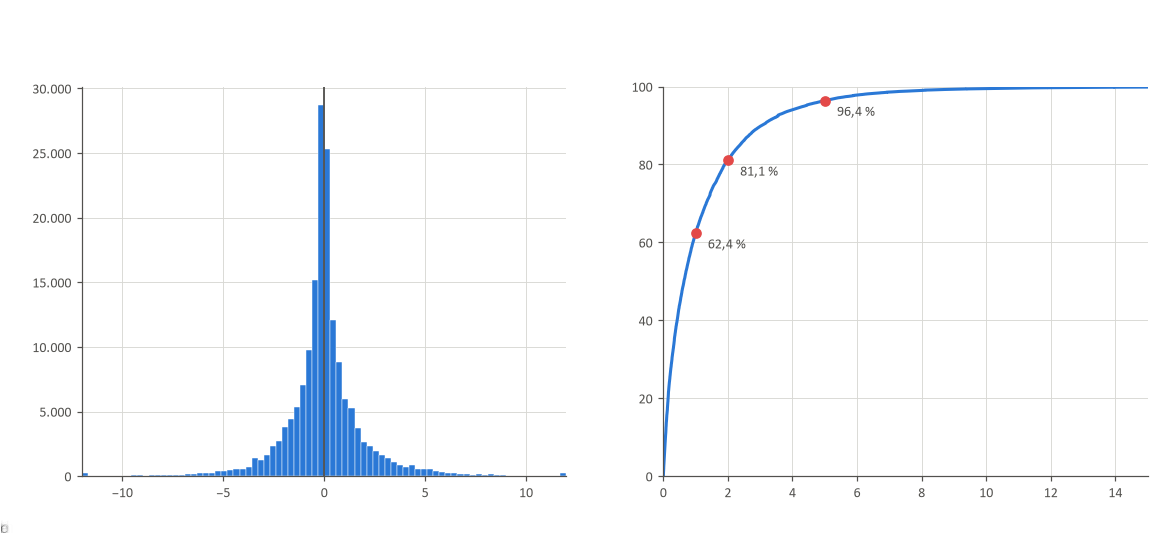

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

LIM = 12
ax1.hist(residuos.clip(-LIM, LIM), bins=80, color=estilo.PALETA[0],
         edgecolor="white", linewidth=0.3)
ax1.axvline(0, color=estilo.GRIS_EJES, lw=1.2)
ax1.set_xlabel("Residuo (g/km)")
ax1.set_ylabel("Vehículos")
ax1.set_xlim(-LIM, LIM)
ax1.yaxis.set_major_formatter(MILES)
ax1.set_title("Distribución de los residuos", fontsize=11, pad=10, loc="left")

# Curva acumulada: qué proporción de vehículos queda por debajo de cada error
orden = np.sort(abs_res.values)
acum = 100 * np.arange(1, len(orden) + 1) / len(orden)
ax2.plot(orden, acum, lw=2, color=estilo.PALETA[0])
for u in (1, 2, 5):
    p = 100 * (abs_res <= u).mean()
    ax2.plot(u, p, marker="o", ms=6, color=estilo.PALETA[7], zorder=3)
    ax2.annotate(f"{es(p, 1)} %", (u, p), textcoords="offset points",
                 xytext=(8, -10), fontsize=9, color=estilo.GRIS_EJES)
ax2.set_xlabel("Error absoluto (g/km)")
ax2.set_ylabel("Vehículos acumulados (%)")
ax2.set_xlim(0, 15)
ax2.set_ylim(0, 100)
ax2.set_title("Proporción de vehículos por debajo de cada error",
              fontsize=11, pad=10, loc="left")

fig.suptitle("Comportamiento del error en el conjunto de prueba",
             fontsize=12.5, y=1.03)
fig.savefig(estilo.DIR_FIGURAS / "fig_13_residuos_distribucion.png")
plt.show()

## 2. ¿Dónde falla el modelo?

Un error medio bajo puede ocultar un comportamiento desigual entre subgrupos.
Se examina el error por tipo de combustible y por tramo de emisiones, que es
donde cabe esperar las diferencias.

In [4]:
diag = pd.DataFrame({
    "real": y_pru, "pred": pred, "residuo": residuos, "abs": abs_res,
    "combustible": X_pru["ft_norm"].astype(str),
})
diag["tramo"] = pd.cut(diag["real"], [0, 100, 120, 140, 160, 200, 600],
                       labels=["<100", "100-120", "120-140", "140-160",
                               "160-200", ">200"])

por_comb = (diag.groupby("combustible")
            .agg(vehiculos=("abs", "size"), mae=("abs", "mean"),
                 sesgo=("residuo", "mean"))
            .sort_values("vehiculos", ascending=False))
por_tramo = (diag.groupby("tramo", observed=True)
             .agg(vehiculos=("abs", "size"), mae=("abs", "mean"),
                  sesgo=("residuo", "mean")))

print("Por combustible:"); print(por_comb.round(3).to_string())
print("\nPor tramo de emisiones (g/km):"); print(por_tramo.round(3).to_string())

Por combustible:
             vehiculos    mae  sesgo
combustible                         
petrol          128579  1.133  0.000
diesel           32309  1.789  0.003
lpg               6439  0.352  0.005
e85                550  1.166 -0.032
ng                  60  0.830 -0.415

Por tramo de emisiones (g/km):
         vehiculos    mae  sesgo
tramo                           
<100          5693  0.537 -0.122
100-120      48599  0.787 -0.202
120-140      66750  1.239 -0.022
140-160      28352  1.590  0.237
160-200      13073  1.955  0.286
>200          5470  2.173  0.302


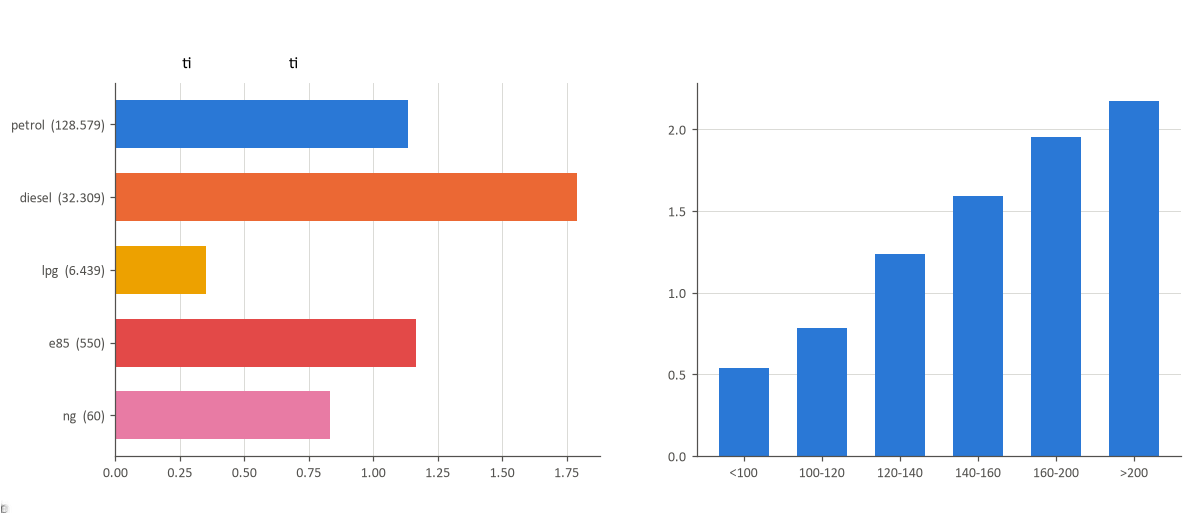

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

c1 = [estilo.color_de(f) for f in por_comb.index]
ax1.barh(range(len(por_comb)), por_comb["mae"], color=c1, height=0.66)
for i, v in enumerate(por_comb["mae"]):
    ax1.text(v + 0.05, i, f"{es(v, 2)}", va="center", fontsize=8.5,
             color=estilo.GRIS_EJES)
ax1.set_yticks(range(len(por_comb)))
ax1.set_yticklabels([f"{f}  ({es(n)})" for f, n in
                     zip(por_comb.index, por_comb.vehiculos)], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel("Error absoluto medio (g/km)")
ax1.grid(axis="y", visible=False)
ax1.set_title("Error por tipo de combustible", fontsize=11, pad=10, loc="left")

ax2.bar(range(len(por_tramo)), por_tramo["mae"], color=estilo.PALETA[0],
        width=0.64)
for i, v in enumerate(por_tramo["mae"]):
    ax2.text(i, v + 0.05, f"{es(v, 2)}", ha="center", fontsize=8.5,
             color=estilo.GRIS_EJES)
ax2.set_xticks(range(len(por_tramo)))
ax2.set_xticklabels(por_tramo.index, fontsize=9)
ax2.set_xlabel("Tramo de emisiones reales (g/km)")
ax2.set_ylabel("Error absoluto medio (g/km)")
ax2.grid(axis="x", visible=False)
ax2.set_title("Error por nivel de emisiones", fontsize=11, pad=10, loc="left")

fig.suptitle("Distribución del error entre subgrupos", fontsize=12.5, y=1.03)
fig.savefig(estilo.DIR_FIGURAS / "fig_14_error_subgrupos.png")
plt.show()

## 3. Interpretabilidad: valores SHAP

Las medidas de importancia empleadas hasta ahora indican qué variables usa el
modelo, pero no en qué dirección ni con qué intensidad afecta cada una a cada
predicción concreta. Los valores SHAP resuelven ambas cuestiones: reparten la
diferencia entre la predicción y la media global entre las variables que la
originan, de modo que la suma de las contribuciones más el valor base reproduce
exactamente la predicción.

Se calculan mediante el algoritmo TreeSHAP implementado en LightGBM, que los
obtiene de forma exacta aprovechando la estructura del árbol. La ventaja para la
lectura es que vienen expresados en gramos por kilómetro.

In [6]:
MUESTRA_SHAP = 20_000
sub = X_pru.sample(MUESTRA_SHAP, random_state=SEMILLA)
shap = modelo.booster_.predict(sub, pred_contrib=True)
valores, base = shap[:, :-1], shap[0, -1]

# Comprobación de la propiedad aditiva: contribuciones más base igual predicción
desv = np.abs(shap.sum(axis=1) - modelo.predict(sub)).max()
print(f"Valor base (predicción media): {base:.2f} g/km")
print(f"Desviación máxima de la propiedad aditiva: {desv:.2e}")

imp = (pd.Series(np.abs(valores).mean(axis=0), index=sub.columns)
       .sort_values(ascending=False))
print("\nContribución media absoluta de cada variable (g/km):")
print(imp.round(3).rename(index=ETIQUETAS).to_string())

Valor base (predicción media): 133.80 g/km
Desviación máxima de la propiedad aditiva: 5.63e-12

Contribución media absoluta de cada variable (g/km):
Potencia                8.478
Masa                    7.449
Modo de alimentación    6.251
Marca                   3.349
Combustible             1.467
Cilindrada/kW           1.246
Cilindrada              1.188
Ecoinnovación           0.912
País                    0.466
Agrupación              0.309


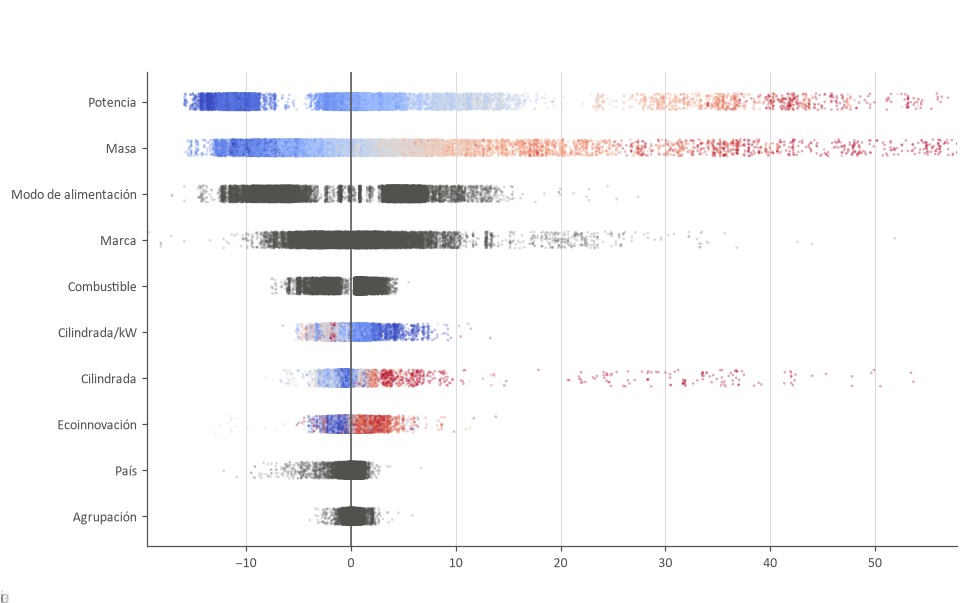

In [7]:
# Gráfico de enjambre: cada punto es un vehículo, su posición horizontal la
# contribución de esa variable a su predicción, y el color el valor de la
# variable. Permite ver a la vez cuánto pesa cada una y en qué dirección.
orden = imp.index.tolist()[::-1]
fig, ax = plt.subplots(figsize=(9.5, 5.6))
rng = np.random.default_rng(SEMILLA)

for i, var in enumerate(orden):
    j = list(sub.columns).index(var)
    v = valores[:, j]
    y_pos = i + rng.uniform(-0.18, 0.18, len(v))
    if var in NUMERICAS:
        col = sub[var].astype(float).values
        norm = (col - np.nanpercentile(col, 2)) / (np.nanpercentile(col, 98) -
                                                   np.nanpercentile(col, 2) + 1e-9)
        ax.scatter(v, y_pos, c=np.clip(norm, 0, 1), cmap="coolwarm", s=3,
                   alpha=0.35, edgecolor="none", vmin=0, vmax=1)
    else:
        ax.scatter(v, y_pos, color=estilo.GRIS_EJES, s=3, alpha=0.22,
                   edgecolor="none")

ax.axvline(0, color=estilo.GRIS_EJES, lw=1)
ax.set_yticks(range(len(orden)))
ax.set_yticklabels([ETIQUETAS.get(v, v) for v in orden], fontsize=9)
ax.set_xlabel("Contribución a la predicción (g/km)")
# El eje se ajusta al recorrido real de las contribuciones, recortando el
# 0,2 % extremo de cada lado para que la nube central sea legible.
lim_i, lim_s = np.percentile(valores, [0.2, 99.8])
margen = 0.08 * (lim_s - lim_i)
ax.set_xlim(lim_i - margen, lim_s + margen)
ax.grid(axis="y", visible=False)
ax.set_title("Contribución de cada variable a las predicciones individuales\n"
             "Azul: valor bajo de la variable · Rojo: valor alto · Gris: variable categórica",
             fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_15_shap_enjambre.png")
plt.show()

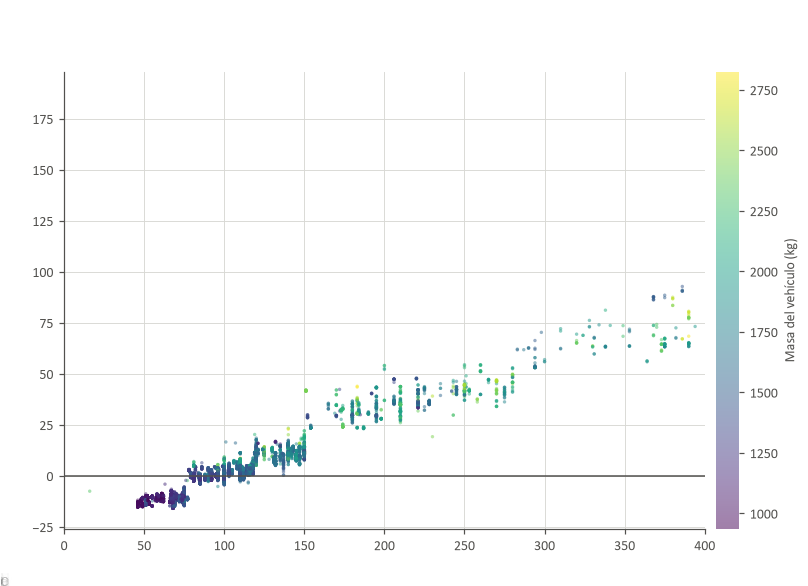

In [8]:
# Gráfico de dependencia: cómo cambia la contribución de la potencia según su
# propio valor, coloreado por masa para revelar la interacción entre ambas.
j = list(sub.columns).index("Ep (KW)")
fig, ax = plt.subplots(figsize=(9, 5.4))
sc = ax.scatter(sub["Ep (KW)"], valores[:, j], c=sub["M (kg)"],
                cmap="viridis", s=5, alpha=0.5, edgecolor="none")
ax.axhline(0, color=estilo.GRIS_EJES, lw=1)
ax.set_xlabel("Potencia del motor (kW)")
ax.set_ylabel("Contribución de la potencia (g/km)")
ax.set_xlim(0, 400)
cb = fig.colorbar(sc, ax=ax, pad=0.015)
cb.set_label("Masa del vehículo (kg)", fontsize=9)
cb.outline.set_visible(False)
ax.set_title("Efecto de la potencia sobre la predicción\n"
             "Cada punto es un vehículo del conjunto de prueba",
             fontsize=12.5, pad=14, loc="left")
fig.savefig(estilo.DIR_FIGURAS / "fig_16_shap_potencia.png")
plt.show()

## 4. Comparativa de resultados

Se reúnen las métricas de todas las alternativas ensayadas a lo largo del
trabajo, medidas sobre el mismo conjunto de prueba.

In [9]:
COMPARATIVA = [
    ("Regresión lineal",              7.281, 10.222, 0.871),
    ("Random Forest",                 1.575,  3.061, 0.988),
    ("LightGBM sin ajustar",          1.740,  2.743, 0.991),
    ("LightGBM ajustado",             None,   None,  None),
    ("LightGBM, solo variables físicas", 2.112, 3.477, 0.985),
]
filas = []
for nombre, mae, rmse, r2 in COMPARATIVA:
    if mae is None:
        mae = mean_absolute_error(y_pru, pred)
        rmse = np.sqrt(mean_squared_error(y_pru, pred))
        r2 = r2_score(y_pru, pred)
    filas.append({"modelo": nombre, "MAE": mae, "RMSE": rmse, "R2": r2})

resumen = pd.DataFrame(filas)
resumen["error relativo %"] = 100 * resumen.MAE / y_pru.median()
print(resumen.round(3).to_string(index=False))

(MODELOS / "comparativa_final.json").write_text(
    json.dumps({"conjunto_prueba": int(len(y_pru)),
                "mediana_objetivo": float(y_pru.median()),
                "modelos": resumen.to_dict("records")},
               indent=2, ensure_ascii=False), encoding="utf-8")
print("\nGuardado en modelos/comparativa_final.json")

                          modelo   MAE   RMSE    R2  error relativo %
                Regresión lineal 7.281 10.222 0.871             5.688
                   Random Forest 1.575  3.061 0.988             1.230
            LightGBM sin ajustar 1.740  2.743 0.991             1.359
               LightGBM ajustado 1.230  2.183 0.994             0.961
LightGBM, solo variables físicas 2.112  3.477 0.985             1.650

Guardado en modelos/comparativa_final.json
